# SPACEFish Single-File Workbench

This notebook consolidates the SPACEFish text files into one place so you can edit subprocesses quickly.

- Nextflow module files (`*.nf.txt`) are included as **reference markdown cells**.
- Python script files (`*.txt`) are included as **editable code cells**.
- This setup is intended for **single-file, sequential debugging** (no parallelisation).

You can copy functions/classes from code cells into a small runner section at the bottom and execute step-by-step for one sample.


In [43]:
# Centralized imports (cleaned)
from bioio import BioImage
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tifffile import imwrite, imread
import tifffile
from skimage.segmentation import expand_labels, clear_border
from skimage.measure import regionprops_table
from cellpose import models
import napari
from liffile import LifFile
import matplotlib.colors as mcolors
import colorsys
from spotiflow.model import Spotiflow
from scipy.spatial import KDTree
from skimage.measure import regionprops
from skimage.transform import resize
from pathlib import Path
import pandas as pd
import scipy.ndimage as ndi
from skimage.measure import regionprops

from ConcatSpots import ConcatSpots
from FilterSpots import FilterSpots
from Decoding import Decoding
from CountTable import CountTable

# Set custom colour scheme for plots and visualisation
custom_colours = ["dodgerblue", "darkorange", "yellow", "limegreen", "red", "darkviolet", "deeppink"]

available = torch.cuda.is_available()
device_count = torch.cuda.device_count() if available else 0
device_name = torch.cuda.get_device_name(0) if available and device_count > 0 else None

status = {
    "cuda_available": available,
    "device_count": device_count,
    "device_name": device_name,
}
print(status)

{'cuda_available': True, 'device_count': 1, 'device_name': 'NVIDIA GeForce RTX 5080'}


In [96]:
def open_and_extract_dapi_and_voxel_size(source_path, image_index=0, DAPI_channel=-2):
    source_path, z_um, y_um, x_um, dapi_image = str(source_path), None, None, None, None
    try:
        if source_path.lower().endswith(".lif"):
            with LifFile(source_path) as lif:
                idx = int(image_index or 0)
                if idx < 0 or idx >= len(lif.images):
                    print("Bad index")
                    return None, (None, None, None)
                img = lif.images[idx]
                xa = img.asxarray()
                dims = {str(d).lower(): d for d in xa.dims}
                if "t" in dims: xa = xa.isel({dims["t"]: 0})
                if "c" in dims: xa = xa.isel({dims["c"]: DAPI_channel})
                if all(k in dims for k in ("z", "y", "x")): xa = xa.transpose(dims["z"], dims["y"], dims["x"])
                dapi_image = np.asarray(xa)
                if dapi_image.ndim == 2: dapi_image = dapi_image[None, :, :]
                coords = getattr(img, "coords", None)
                if isinstance(coords, dict):
                    for axis in ("X", "Y", "Z"):
                        coord = coords.get(axis)
                        if coord is not None and len(coord) >= 2:
                            step_um = abs(float(coord[1] - coord[0])) * 1e6
                            if np.isfinite(step_um) and step_um > 0:
                                if axis == "X": x_um = step_um
                                elif axis == "Y": y_um = step_um
                                else: z_um = step_um

        elif source_path.lower().endswith((".tif", ".tiff")):
            with tifffile.TiffFile(source_path) as tif:
                series = tif.series[0]
                arr, axes = np.asarray(series.asarray()), (series.axes or "").upper()
                if "T" in axes:
                    arr = np.take(arr, indices=0, axis=axes.index("T")); axes = axes.replace("T", "")
                if "C" in axes:
                    arr = np.take(arr, indices=DAPI_channel, axis=axes.index("C")); axes = axes.replace("C", "")
                if set("ZYX").issubset(set(axes)) and arr.ndim >= 3:
                    dapi_image = np.transpose(arr, [axes.index("Z"), axes.index("Y"), axes.index("X")])
                elif set("YX").issubset(set(axes)) and arr.ndim == 2:
                    dapi_image = arr[None, :, :]
                else:
                    dapi_image = np.asarray(arr)
                tags = {tag.name: tag.value for tag in tif.pages[0].tags.values()}
                if "XResolution" in tags: x_um = 1.0 / (float(tags["XResolution"][0]) / float(tags["XResolution"][1]))
                if "YResolution" in tags: y_um = 1.0 / (float(tags["YResolution"][0]) / float(tags["YResolution"][1]))
                if "IJMetadata" in tags and "nscales=" in str(tags["IJMetadata"]):
                    z_um = float(str(tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
                elif "ImageDescription" in tags and "spacing=" in str(tags["ImageDescription"]):
                    z_um = float(str(tags["ImageDescription"]).split("spacing=")[1].split("loop")[0])
    except Exception:
        return None, (None, None, None)
    if x_um is None and y_um is not None: x_um = y_um
    if y_um is None and x_um is not None: y_um = x_um
    return dapi_image, (z_um, y_um, x_um)

In [4]:
_CELLPOSE_MODEL_CACHE = {}

def cellpose_comparisons(
    path,
    dapi_image,
    z_anisotropy,
    min_size=500,
    stitch_threshold=0.1,
    downsample_factor=2,
    batch_size_3d=128,
    resample_3d=False,
    model_path=r"C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\cellpose_model",
):
    downsample_factor = int(downsample_factor)
    shape = np.array(dapi_image.shape)
    pad = ((-shape) % downsample_factor).astype(int)
    if np.any(pad):
        dapi_image = np.pad(dapi_image, ((0, pad[0]), (0, pad[1]), (0, pad[2])), mode="constant", constant_values=0)

    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    tensor = torch.from_numpy(dapi_image).to(device="cuda", dtype=torch.float16)[None, None]
    dapi_image_ds = torch.nn.functional.avg_pool3d(
        tensor, kernel_size=downsample_factor, stride=downsample_factor
    )[0, 0].float().cpu().numpy()

    model_key = str(model_path)
    if model_key not in _CELLPOSE_MODEL_CACHE:
        _CELLPOSE_MODEL_CACHE[model_key] = models.CellposeModel(gpu=True, pretrained_model=str(model_path))
    model = _CELLPOSE_MODEL_CACHE[model_key]
    stem = Path(path).stem

    print("running 2d (with stitching)")
    masks_2d_stitched, _, _ = model.eval(
        dapi_image_ds,
        anisotropy=z_anisotropy,
        do_3D=False,
        min_size=min_size,
        stitch_threshold=stitch_threshold,
        z_axis=0,
    )
    imwrite(f"{stem}_2dstitch_masks.tif", np.asarray(masks_2d_stitched, dtype=np.uint32))

    print("running 3d")
    masks_3d, _, _ = model.eval(
        dapi_image_ds,
        do_3D=True,
        anisotropy=z_anisotropy,
        min_size=min_size,
        z_axis=0,
        batch_size=int(batch_size_3d),
        resample=bool(resample_3d),
    )
    imwrite(f"{stem}_3dmasks.tif", np.asarray(masks_3d, dtype=np.uint32))
    return masks_2d_stitched, masks_3d, dapi_image_ds

In [5]:
def custom_napari_palette(n_labels, base_colour, hue_span=0.02, sat_span=0.45, light_span=0.45, seed=0, alpha=1.0):
    """Build a varied Napari label colormap by jittering H/S/L around a base Matplotlib color."""
    n_labels = int(n_labels)
    if n_labels < 1:
        return {0: np.array([0.0, 0.0, 0.0, 0.0], dtype=float)}

    rng = np.random.default_rng(seed)
    r, g, b = mcolors.to_rgb(base_colour)
    base_h, base_l, base_s = colorsys.rgb_to_hls(r, g, b)

    hue = (base_h + rng.uniform(-hue_span, hue_span, n_labels)) % 1.0
    sat = np.clip(base_s + rng.uniform(-sat_span, sat_span, n_labels), 0.20, 1.00)
    light = np.clip(base_l + rng.uniform(-light_span, light_span, n_labels), 0.18, 0.88)

    order = rng.permutation(n_labels)
    custom_colormap = {0: np.array([0.0, 0.0, 0.0, 0.0], dtype=float)}
    for idx, j in enumerate(order, start=1):
        pr, pg, pb = colorsys.hls_to_rgb(float(hue[j]), float(light[j]), float(sat[j]))
        custom_colormap[idx] = np.array([pr, pg, pb, float(alpha)], dtype=float)
    return custom_colormap

In [97]:
lif_path = r"z:\Jorge\20250524_sprouts\20250524_dev4_1_sprout_merges.lif"
dapi_image, (z_um, y_um, x_um) = open_and_extract_dapi_and_voxel_size(lif_path, image_index=1, DAPI_channel=-2)
z_anisotropy = z_um / x_um

In [9]:
# masks_2d_stitched, masks_3d, downscaled_dapi = cellpose_comparisons(
#     lif_path,
#     dapi_image,
#     z_anisotropy,
#     min_size=500,
#     stitch_threshold=0.1,
#     downsample_factor=2,
#     batch_size_3d=128,
#     resample_3d=False,
# )
masks_2d_stitched = imread(r"./outputs/20250524_dev4_1_sprout_merge2_dapi_phase_2d_masks.tif")
masks_3d = expand_labels(imread(r"./outputs/20250524_dev4_1_sprout_merge2_dapi_phase_3dmasks.tif"))

In [12]:
nlabels = max(np.max(masks_2d_stitched), np.max(masks_3d))
print(nlabels)

115


In [13]:
downsample_factor = 2  # must match cellpose_comparisons(..., downsample_factor=...)
good_labels_ds = expand_labels(masks_3d, distance=3)
good_labels_us = np.repeat(np.repeat(np.repeat(good_labels_ds, downsample_factor, axis=0), downsample_factor, axis=1), downsample_factor, axis=2)
good_labels_us = clear_border(good_labels_us[: dapi_image.shape[0], : dapi_image.shape[1], : dapi_image.shape[2]])
table = pd.DataFrame(regionprops_table(good_labels_us, properties=("label", "area")))

In [14]:
def open_and_extract_spots_channels(source_path, image_index=0, dapi_channel=7, spots_channels=(1, 2, 3, 4, 5, 6)):
    source_path = str(source_path)
    if source_path.lower().endswith(".lif"):
        with LifFile(source_path) as lif:
            xa = lif.images[int(image_index)].asxarray()
            dims = {str(d).lower(): d for d in xa.dims}
            if "t" in dims:
                xa = xa.isel({dims["t"]: 0})
                dims = {str(d).lower(): d for d in xa.dims}
            if "c" not in dims:
                raise ValueError("No channel axis found in LIF image")
            dapi_xa = xa.isel({dims["c"]: int(dapi_channel)})
            spots_xa = xa.isel({dims["c"]: list(spots_channels)})
            dapi_dims = {str(d).lower(): d for d in dapi_xa.dims}
            spots_dims = {str(d).lower(): d for d in spots_xa.dims}
            if all(k in dapi_dims for k in ("z", "y", "x")):
                dapi_xa = dapi_xa.transpose(dapi_dims["z"], dapi_dims["y"], dapi_dims["x"])
            elif all(k in dapi_dims for k in ("y", "x")):
                dapi_xa = dapi_xa.transpose(dapi_dims["y"], dapi_dims["x"])
            if all(k in spots_dims for k in ("c", "z", "y", "x")):
                spots_xa = spots_xa.transpose(spots_dims["c"], spots_dims["z"], spots_dims["y"], spots_dims["x"])
            elif all(k in spots_dims for k in ("c", "y", "x")):
                spots_xa = spots_xa.transpose(spots_dims["c"], spots_dims["y"], spots_dims["x"])
            dapi_stack = np.asarray(dapi_xa)
            spots_stack = np.asarray(spots_xa)
            if dapi_stack.ndim == 2:
                dapi_stack = dapi_stack[None, :, :]
            if spots_stack.ndim == 3:
                spots_stack = spots_stack[:, None, :, :]
            return dapi_stack, spots_stack
    if source_path.lower().endswith((".tif", ".tiff")):
        with tifffile.TiffFile(source_path) as tif:
            series = tif.series[0]
            arr, axes = np.asarray(series.asarray()), (series.axes or "").upper()
            if "T" in axes:
                arr = np.take(arr, indices=0, axis=axes.index("T"))
                axes = axes.replace("T", "")
            if "C" not in axes:
                raise ValueError("No channel axis found in TIFF image")
            c_axis = axes.index("C")
            dapi_stack = np.take(arr, indices=int(dapi_channel), axis=c_axis)
            spots_stack = np.take(arr, indices=list(spots_channels), axis=c_axis)
            dapi_axes = axes.replace("C", "")
            spots_axes = axes
            if all(k in dapi_axes for k in "ZYX") and dapi_stack.ndim >= 3:
                dapi_stack = np.transpose(dapi_stack, [dapi_axes.index("Z"), dapi_axes.index("Y"), dapi_axes.index("X")])
            elif all(k in dapi_axes for k in "YX") and dapi_stack.ndim == 2:
                dapi_stack = dapi_stack[None, :, :]
            if all(k in spots_axes for k in "CZYX") and spots_stack.ndim >= 4:
                spots_stack = np.transpose(spots_stack, [spots_axes.index("C"), spots_axes.index("Z"), spots_axes.index("Y"), spots_axes.index("X")])
            elif all(k in spots_axes for k in "CYX") and spots_stack.ndim == 3:
                spots_stack = spots_stack[:, None, :, :]
            return np.asarray(dapi_stack), np.asarray(spots_stack)
    raise ValueError(f"Unsupported file format: {source_path}")

In [ ]:
dapi_fs, spots_fs = open_and_extract_spots_channels(
    r"z:\Jorge\20250524_sprouts\20250524_dev4_1_sprout_merges.lif",
    image_index=1,
    dapi_channel=6,
    spots_channels=(0, 1, 2, 3, 4, 5),
)

In [26]:
dapi_fs.shape, spots_fs.shape

((95, 5787, 3957), (6, 95, 5787, 3957))

In [ ]:
viewer = napari.Viewer()
viewer.add_image(dapi_fs, name = "dapi")
viewer.add_image(spots_fs, name = "spots")
viewer.add_labels(good_labels_us)

<Labels layer 'good_labels_us' at 0x2a2c6db97e0>

In [87]:
from pathlib import Path
import importlib
import legacy_pipeline_runner

importlib.reload(legacy_pipeline_runner)

results = legacy_pipeline_runner.run_legacy_pipeline_from_arrays(
    image_name="bel_spacefish_from_arrays",
    spots_stack=spots_fs,
    dapi_stack=dapi_fs,
    labels_3d=good_labels_us,
    metadata_path=Path(r"C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\dummy.csv"),
    output_dir=Path.cwd() / "legacy_pipeline_outputs",
    run_normalization=True,
    make_count_table=True,
    write_full_inputs=False,
)
results

Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0002_cropped.tif
Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0004_cropped.tif
Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0006_cropped.tif
Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0008_cropped.tif
Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0012_cropped.tif
Image has been saved at this location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\

Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0002_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0002_cropped.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 0


Current channel: 0
INFO:spotiflow.model.spotiflow:Will use device: cuda:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (210, 274)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (224, 288, 1)
INFO:spotiflow.model.spotiflow:Found 0 spots
No spots where detected in channel 1 of nucleus 2.
Current channel: 1
INFO:spotiflow.model.spotiflow:Will use device: cuda:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (210, 274)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (224, 288,

Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0004_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0004_cropped.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 0


Current channel: 0
INFO:spotiflow.model.spotiflow:Will use device: cuda:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (250, 348)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 352, 1)
INFO:spotiflow.model.spotiflow:Found 0 spots
No spots where detected in channel 1 of nucleus 4.
Current channel: 1
INFO:spotiflow.model.spotiflow:Will use device: cuda:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (250, 348)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 352,

...

Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0083_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0083_cropped.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 0
Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0084_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0084_cropped.tif'. Failed to parse XML for the provided file. Error: not well-for

bel_spacefish_from_arrays-81 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0081-normalised.tif.
bel_spacefish_from_arrays-83 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0083-normalised.tif.
bel_spacefish_from_arrays-84 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0084-normalised.tif.


Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0086_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0086_cropped.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 0
Attempted file (C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0087_cropped.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: 'C:/Users/taylorhearn/git_repos/image_quantification/New_Spacefish/legacy_pipeline_outputs/bel_spacefish_from_arrays-nucleus0087_cropped.tif'. Failed to parse XML for the provided file. Error: not well-for

bel_spacefish_from_arrays-86 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0086-normalised.tif.
bel_spacefish_from_arrays-87 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0087-normalised.tif.
bel_spacefish_from_arrays-99 was saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-nucleus0099-normalised.tif.
Statistics on nuclei are saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\nuclei_stats_normalized_nucleus99.csv
Statistics on nuclei are saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays_NucleiStats_normalized.csv
Concatenated spots are saved at C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legac

{'spots_path': None,
 'dapi_path': None,
 'mask_path': 'C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-seg_mask.tif',
 'cropped_files': ['C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-nucleus0002_cropped.tif',
  'C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-nucleus0004_cropped.tif',
  'C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-nucleus0006_cropped.tif',
  'C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-nucleus0008_cropped.tif',
  'C:\\Users\\taylorhearn\\git_repos\\image_quantification\\New_Spacefish\\legacy_pipeline_outputs\\bel_spacefish_from_arrays-nucleus0012_cropped.tif',
  'C:\\Users\\taylorhearn\\gi

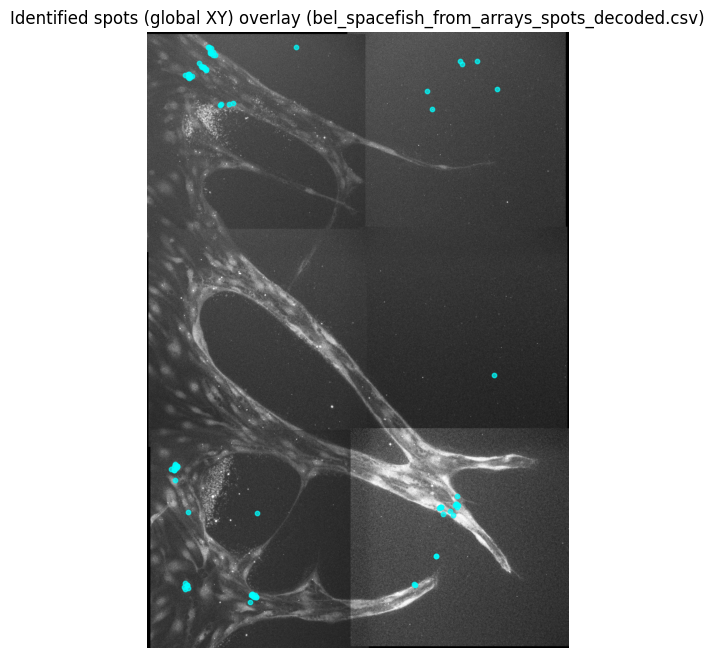

Using spots table: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays_spots_decoded.csv
Using nuclei location: C:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\legacy_pipeline_outputs\bel_spacefish_from_arrays-NucleiLocation.csv
Total spots plotted (global XY): 84
local columns used: x=x, y=y


In [94]:
# Visualize identified spots on a max-projection image (global XY)
import pandas as pd
import matplotlib.pyplot as plt

channel_idx = 0  # which spot channel from spots_fs to display

candidate_paths = [
    results.get("decoded_spots_path") if isinstance(results, dict) else None,
    results.get("filtered_spots_path") if isinstance(results, dict) else None,
    results.get("concat_spots_path") if isinstance(results, dict) else None,
]
spot_table_path = next((p for p in candidate_paths if p and Path(p).exists()), None)
if spot_table_path is None:
    raise FileNotFoundError("No spot table found in results (decoded/filtered/concat).")

spots_df = pd.read_csv(spot_table_path)

image_name_guess = "bel_spacefish_from_arrays"
if isinstance(results, dict) and results.get("decoded_spots_path"):
    image_name_guess = Path(results["decoded_spots_path"]).name.split("_spots_")[0]
nuc_loc_path = Path(spot_table_path).parent / f"{image_name_guess}-NucleiLocation.csv"
if not nuc_loc_path.exists():
    raise FileNotFoundError(f"Nuclei location file not found: {nuc_loc_path}")

loc_df = pd.read_csv(nuc_loc_path)
if "nucleus" not in spots_df.columns:
    raise ValueError(f"Spots table missing nucleus column: {spot_table_path}")
if not {"nucleus", "ystart", "xstart"}.issubset(loc_df.columns):
    raise ValueError(f"Nuclei location table missing required columns: {list(loc_df.columns)}")

spots_df["nucleus"] = spots_df["nucleus"].astype(int)
loc_df["nucleus"] = loc_df["nucleus"].astype(int)
spots_df = spots_df.merge(loc_df[["nucleus", "ystart", "xstart"]], on="nucleus", how="left")

x_candidates = ["x", "X", "x_source", "x_um"]
y_candidates = ["y", "Y", "y_source", "y_um"]
x_local_col = next((c for c in x_candidates if c in spots_df.columns), None)
y_local_col = next((c for c in y_candidates if c in spots_df.columns), None)
if x_local_col is None or y_local_col is None:
    raise ValueError(f"Could not find local x/y columns in {spot_table_path}. Found columns: {list(spots_df.columns)}")

spots_df = spots_df.dropna(subset=["xstart", "ystart"])
spots_df["x_global"] = spots_df[x_local_col].astype(float) + spots_df["xstart"].astype(float)
spots_df["y_global"] = spots_df[y_local_col].astype(float) + spots_df["ystart"].astype(float)

img2d = spots_fs[int(channel_idx)].max(axis=0)

plt.figure(figsize=(8, 8))
plt.imshow(img2d, cmap="gray")
plt.scatter(spots_df["x_global"].values, spots_df["y_global"].values, s=10, c="cyan", alpha=0.7)
plt.title(f"Identified spots (global XY) overlay ({Path(spot_table_path).name})")
plt.axis("off")
plt.show()

print(f"Using spots table: {spot_table_path}")
print(f"Using nuclei location: {nuc_loc_path}")
print(f"Total spots plotted (global XY): {len(spots_df)}")
print(f"local columns used: x={x_local_col}, y={y_local_col}")